### Exercise for Graph 4
Your task:
1) Make the graph on the right! You will need to make use of 2 conditional edges!

2) Input:initial_atate = AgentState(number1 = 10 ,operation = - ,number 2 = 5 ,number 3 = 7 number 4 = 2  operation2 = +\finalNumber \finalNumber2 )
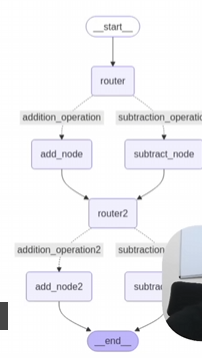

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END

class AgentState(TypedDict):
    number1:int
    operation:str
    number2:int
    number3:int
    operation2:str
    number4:int
    finalnumber:int
    finalnumber2:int


In [4]:

def adder(state:AgentState) ->AgentState:
    """this node adds the number1 and number2"""
    state["finalnumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state:AgentState) ->AgentState:
    """this node subtaacts the number1 and number2"""
    state["finalnumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state:AgentState) ->str:
    """this node will select the next node of the graph"""
    if state["operation"] == "+":
        return "additional_operation1"
    elif state["operation"] == "-":
        return "subtraction_operation1"

def adder2(state:AgentState) ->AgentState:
    """this node adds the number3 and number4"""
    state["finalnumber2"] = state["number3"] + state["number4"]
    return state
def subtractor2(state:AgentState) ->AgentState:
    """this node subtaacts the number3 and number4"""
    state["finalnumber2"] = state["number3"] - state["number4"]
    return state
def decide_next_node2(state:AgentState) ->str:
    """this node will select the next node of the graph"""
    if state["operation2"] == "+":
        return "additional_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"




In [5]:
graph = StateGraph(AgentState)
graph.add_node("add_node",adder)
graph.add_node("subtract_node",subtractor)
graph.add_node("add_node2",adder2)
graph.add_node("subtract_node2",subtractor2)
graph.add_node("router",lambda state:state)
graph.add_node("router2",lambda state:state)

graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
         "additional_operation1":"add_node",
         "subtraction_operation1": "subtract_node"
    }
)
graph.add_edge("add_node","router2")
graph.add_edge("subtract_node","router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "additional_operation2":"add_node2",
        "subtraction_operation2":"subtract_node2"
    }
)

graph.add_edge("add_node2",END)
graph.add_edge("subtract_node2",END)

app = graph.compile()

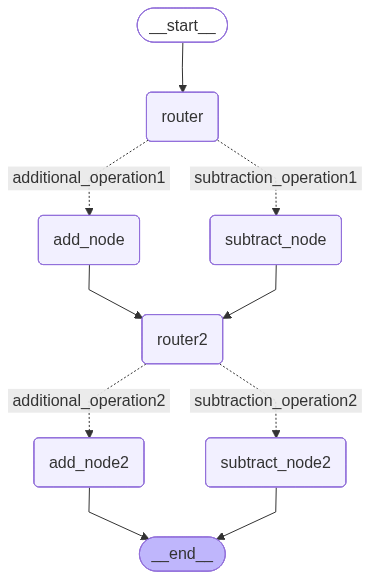

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
initial_state = AgentState(number1 = 10, operation="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber= 0, finalNumber2 = 0)
print(app.invoke(initial_state))

{'number1': 10, 'operation': '-', 'number2': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalnumber': 5, 'finalnumber2': 9}
